In [ ]:
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
data = fetch_ucirepo(id=555)
X = data.data.features
y = data.data.targets
print(X.head())
print(X.shape)

                 category                            title  \
0  housing/rent/apartment       One BR 507 & 509 Esplanade   
1  housing/rent/apartment      Three BR 146 Lochview Drive   
2  housing/rent/apartment  Three BR 3101 Morningside Drive   
3  housing/rent/apartment            Two BR 209 Aegean Way   
4  housing/rent/apartment         One BR 4805 Marquette NE   

                                                body amenities bathrooms  \
0  This unit is located at 507 & 509 Esplanade, R...       NaN         1   
1  This unit is located at 146 Lochview Drive, Ne...       NaN       1.5   
2  This unit is located at 3101 Morningside Drive...       NaN         2   
3  This unit is located at 209 Aegean Way, Vacavi...       NaN         1   
4  This unit is located at 4805 Marquette NE, Alb...       NaN         1   

  bedrooms currency fee  has_photo pets_allowed  ...  price_display  \
0        1      USD  No  Thumbnail         Cats  ...           2195   
1        3      USD  No  Thu

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0,5,6,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0,5,6,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset shape: (99826, 21)

Price information:
count    99821.000000
mean      1527.208493
std        903.635759
min        100.000000
25%       1014.000000
50%       1350.000000
75%       1795.000000
max      52500.000000
Name: price, dtype: float64

Training samples: 79856
Testing samples: 19965

Rent levels:
price
Medium    26693
Low       26636
High      26527
Name: count, dtype: int64

Decision Tree Results
Depth: 1 | Train: 0.4243 | Test: 0.4284
Depth: 3 | Train: 0.5988 | Test: 0.5948
Depth: 5 | Train: 0.6404 | Test: 0.6356
Depth: 10 | Train: 0.7467 | Test: 0.7295
Depth: None | Train: 0.9774 | Test: 0.816


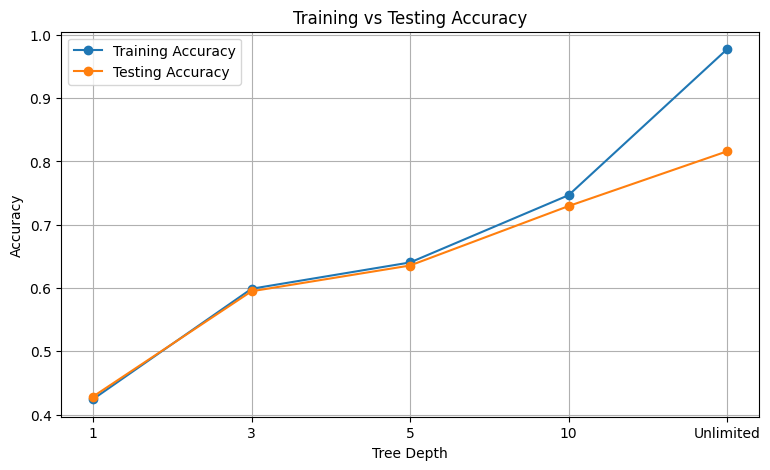


Decision Tree Evaluation
Accuracy : 0.6356
Precision: 0.6218
Recall   : 0.6356
F1 Score : 0.6206

Classification Report
              precision    recall  f1-score   support

        High       0.67      0.77      0.71      6537
         Low       0.66      0.77      0.71      6739
      Medium       0.54      0.37      0.43      6689

    accuracy                           0.64     19965
   macro avg       0.62      0.64      0.62     19965
weighted avg       0.62      0.64      0.62     19965


Confusion Matrix
[[5031  440 1066]
 [ 478 5216 1045]
 [2042 2205 2442]]


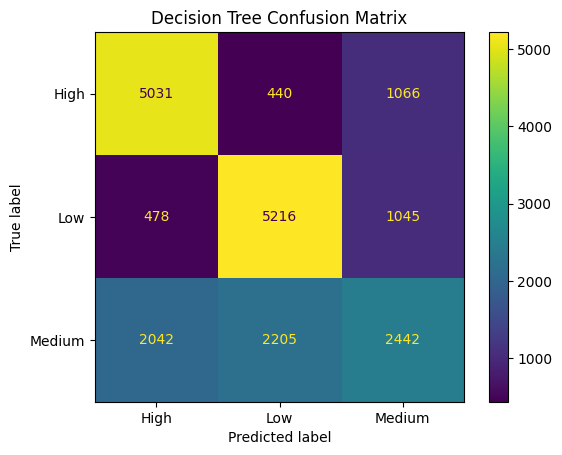

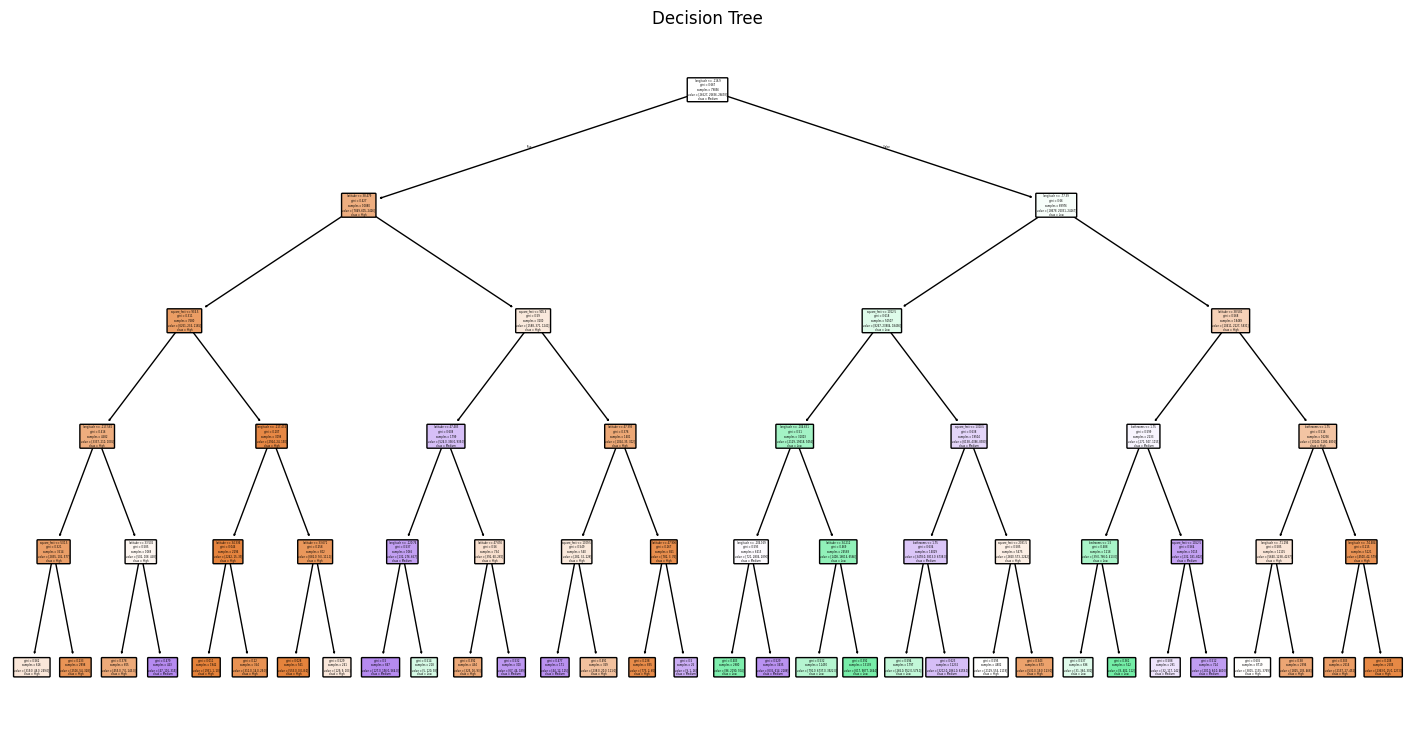


Feature Importance
       Feature  Importance
4    longitude    0.549466
2  square_feet    0.251581
3     latitude    0.124404
0    bathrooms    0.072494
1     bedrooms    0.002055


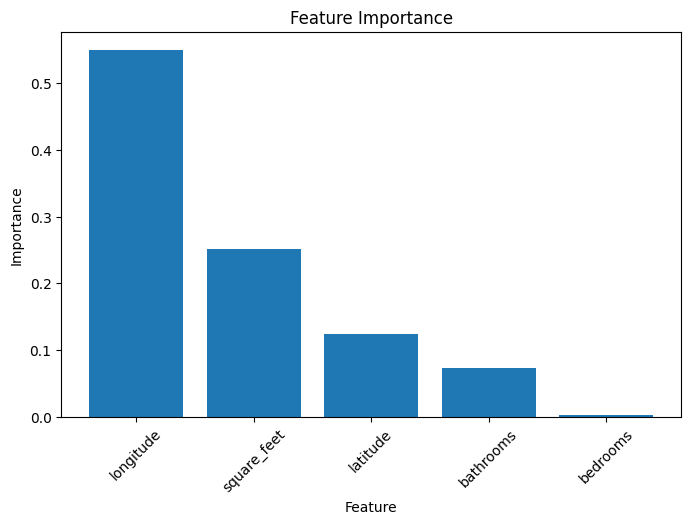


KNN Evaluation
Accuracy : 0.7285
Precision: 0.7253
Recall   : 0.7285
F1 Score : 0.726

Model Comparison
           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.635562   0.621816  0.635562  0.620587
1            KNN  0.728525   0.725274  0.728525  0.725970

New Apartment Prediction
Decision Tree: High
KNN: High


In [ ]:
# Load the real dataset
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
    classification_report,ConfusionMatrixDisplay)
# Load the real dataset
data = fetch_ucirepo(id=555)
df = data.data.features.copy()
print("Dataset shape:", df.shape)
# Prepare the price data
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

print("\nPrice information:")
print(df["price"].describe())

# Use only the numerical features needed for the model
features = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude"
]
X = df[features].copy()
for column in features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

# Split the data
X_train, X_test, price_train, price_test = train_test_split(
    X,
    df["price"],
    test_size=0.20,
    random_state=42
)
print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
# Create the rent levels from training data
q1 = price_train.quantile(1/3)
q2 = price_train.quantile(2/3)
y_train = pd.cut(
    price_train,
    bins=[-float("inf"), q1, q2, float("inf")],
    labels=["Low", "Medium", "High"])

y_test = pd.cut(
    price_test,
    bins=[-float("inf"), q1, q2, float("inf")],
    labels=["Low", "Medium", "High"])

print("\nRent levels:")
print(y_train.value_counts())

# Handle missing values
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Try different tree depths to check underfitting and overfitting
depths = [1, 3, 5, 10, None]
train_scores = []
test_scores = []
print("\nDecision Tree Results")
for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train,train_pred)
    test_accuracy = accuracy_score(y_test,test_pred)
    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)
    print(
        "Depth:", depth,
        "| Train:", round(train_accuracy, 4),
        "| Test:", round(test_accuracy, 4))
# Compare training and testing accuracy
depth_labels = [
    "1",
    "3",
    "5",
    "10",
    "Unlimited"
]
plt.figure(figsize=(9, 5))
plt.plot(
    depth_labels,
    train_scores,
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    depth_labels,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.grid()
plt.show()
# Train the final Decision Tree
final_model = DecisionTreeClassifier(max_depth=5,random_state=42)
final_model.fit(X_train,y_train
)
y_pred = final_model.predict(X_test)
# Evaluate the final model
accuracy = accuracy_score(y_test,y_pred
)
precision = precision_score(y_test,y_pred,average="weighted")
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)
f1 = f1_score(y_test,y_pred,average="weighted")
print("\nDecision Tree Evaluation")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
# Show detailed evaluation results
print("\nClassification Report")
print(classification_report(y_test,y_pred))
# Check which classes are being predicted incorrectly
cm = confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix")
print(cm)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=final_model.classes_)
plt.title("Decision Tree Confusion Matrix")
plt.show()
# Show the Decision Tree
plt.figure(figsize=(18, 9))
plot_tree(final_model,feature_names=features,class_names=final_model.classes_,filled=True,rounded=True
)
plt.title("Decision Tree")
plt.show()
# Check which features are most important
importance = pd.DataFrame({
    "Feature": features,"Importance": final_model.feature_importances_})
importance = importance.sort_values("Importance",ascending=False)
print("\nFeature Importance")
print(importance)
plt.figure(figsize=(8, 5))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()
# Train the KNN model
# KNN uses distances, so the features need to be scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
knn_pred = knn.predict(X_test_scaled)
# Evaluate KNN
knn_accuracy = accuracy_score(y_test,knn_pred)
knn_precision = precision_score(y_test,knn_pred,average="weighted")
knn_recall = recall_score(y_test,knn_pred,average="weighted")
knn_f1 = f1_score(y_test,knn_pred,average="weighted")
print("\nKNN Evaluation")
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1 Score :", round(knn_f1, 4))
# Compare Decision Tree with KNN
comparison = pd.DataFrame({
    "Model": ["Decision Tree","KNN"],"Accuracy": [accuracy,knn_accuracy],
    "Precision": [
        precision,knn_precision
    ],
    "Recall": [
        recall,
        knn_recall
    ],
    "F1 Score": [
        f1,
        knn_f1
    ]})
print("\nModel Comparison")
print(comparison)
# Predict a new apartment
new_apartment = [[
    2,
    3,
    1500,
    40.75,
    -73.98
]]

# Predict using Decision Tree
tree_prediction = final_model.predict(
    new_apartment
)
print("\nNew Apartment Prediction")
print(
    "Decision Tree:",
    tree_prediction[0]
)
# Predict using KNN
new_apartment_scaled = scaler.transform(new_apartment)
knn_prediction = knn.predict(new_apartment_scaled)
print("KNN:",knn_prediction[0])